# Supply Chain Backorder Prediction

## Agent 2 — Risk Detector

**Model:** Stacking Ensemble (Proposed) | XGBoost / LightGBM / CatBoost / BRF / LR
**Target:** `went_on_backorder` (binary classification)
**Dataset:** ~1.9M SKUs, 23 raw features, highly imbalanced (~0.7 % positive)
**Primary metric:** F2-Score (recall-weighted, β = 2)
**Hardware:** Windows + NVIDIA RTX 4070 (GPU-accelerated XGBoost & CatBoost; auto-fallback to CPU)


---

## Step 2 — Install Libraries


In [2]:
# Core libraries (CPU + GPU). The XGBoost and CatBoost pip wheels already
# ship with CUDA support — no special build needed, just a working NVIDIA driver.
%pip install pandas numpy matplotlib seaborn xgboost lightgbm catboost scikit-learn imbalanced-learn shap joblib pyarrow fastparquet scipy --quiet

# OPTIONAL — only used to print a nice "GPU detected: RTX 4070" line in the next
# cell. This notebook does NOT otherwise use PyTorch, and nvidia-smi is used as a
# fallback if torch is absent, so this install is not required:
# %pip install torch torchvision --index-url https://download.pytorch.org/whl/cu130

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


---

## Step 3 — Verify Environment + Detect GPU


In [3]:
# ─────────── Environment check + GPU auto-detection ───────────
import platform, struct, warnings
warnings.filterwarnings('ignore')

print(f'System        : {platform.system()} {platform.release()}')
print(f'Machine       : {platform.machine()}')
print(f'Python bits   : {struct.calcsize("P") * 8}')
print(f'Python version: {platform.python_version()}')

# Detect an NVIDIA GPU (RTX 4070). Prefer torch; fall back to nvidia-smi.
GPU_AVAILABLE, GPU_NAME = False, None
try:
    import torch
    GPU_AVAILABLE = torch.cuda.is_available()
    if GPU_AVAILABLE:
        GPU_NAME = torch.cuda.get_device_name(0)
except Exception:
    import shutil, subprocess
    if shutil.which('nvidia-smi'):
        try:
            out = subprocess.check_output(
                ['nvidia-smi', '--query-gpu=name', '--format=csv,noheader'],
                text=True).strip()
            GPU_AVAILABLE, GPU_NAME = bool(out), out.splitlines()[0]
        except Exception:
            pass

# ── Master switch: set to False to force CPU everywhere ──────
USE_GPU = GPU_AVAILABLE            # auto-detected; override manually if needed

XGB_DEVICE    = 'cuda' if USE_GPU else 'cpu'   # XGBoost 2.x GPU API
CAT_TASK_TYPE = 'GPU'  if USE_GPU else 'CPU'   # CatBoost GPU
# NOTE: LightGBM's default pip wheel has NO GPU support -> it always runs on CPU.
#       BalancedRandomForest / LogisticRegression are sklearn -> CPU only.

if USE_GPU:
    print(f'\n✅ GPU detected : {GPU_NAME}')
    print('   → XGBoost & CatBoost will train on CUDA')
else:
    print('\n⚠️  No CUDA GPU detected — everything will run on CPU')
print(f'   USE_GPU = {USE_GPU}')

System        : Windows 11
Machine       : AMD64
Python bits   : 64
Python version: 3.14.2

✅ GPU detected : NVIDIA GeForce RTX 4070
   → XGBoost & CatBoost will train on CUDA
   USE_GPU = True


---

## Step 4 — Import Libraries


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import shap
import joblib
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, cross_validate
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, recall_score, precision_score,
    fbeta_score, matthews_corrcoef, f1_score,
    PrecisionRecallDisplay, RocCurveDisplay,
    average_precision_score
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

print('✅ All libraries imported successfully')
print(f'   XGBoost  : {xgb.__version__}')
print(f'   Pandas   : {pd.__version__}')
print(f'   NumPy    : {np.__version__}')

import lightgbm as lgb
from catboost import CatBoostClassifier
import scipy


✅ All libraries imported successfully
   XGBoost  : 3.3.0
   Pandas   : 3.0.3
   NumPy    : 2.4.4


---

## Step 5 — Load Dataset


In [5]:
# ─────────────── Paths (Windows local system) ───────────────
DATASET_PATH = Path(r"E:\CSE499B\Project Codes\Risk Detector Classification Model\Dataset\Processed_Dataset.pkl")

# Project root = the "Risk Detector Classification Model" folder (parent of Dataset).
# Outputs are anchored here so they don't depend on where this notebook sits.
PROJECT_ROOT = DATASET_PATH.parent.parent
FIGURES_DIR  = PROJECT_ROOT / "figures"
MODELS_DIR   = PROJECT_ROOT / "models"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_pickle(DATASET_PATH)

print('✅ Dataset loaded')
print(f'   Path   : {DATASET_PATH}')
print(f'   Shape  : {df.shape}')
print(f'   Memory : {df.memory_usage(deep=True).sum() / 1e6:.1f} MB')
print(f'   Figures → {FIGURES_DIR}')
print(f'   Models  → {MODELS_DIR}')
df.head()

✅ Dataset loaded
   Path   : E:\CSE499B\Project Codes\Risk Detector Classification Model\Dataset\Processed_Dataset.pkl
   Shape  : (1929935, 26)
   Memory : 229.7 MB
   Figures → E:\CSE499B\Project Codes\Risk Detector Classification Model\figures
   Models  → E:\CSE499B\Project Codes\Risk Detector Classification Model\models


,national_inv,lead_time,in_transit_qty,forecast_3_month,forecast_6_month,forecast_9_month,sales_1_month,sales_3_month,sales_6_month,sales_9_month,...,deck_risk,oe_constraint,ppap_risk,stop_auto_buy,rev_stop,went_on_backorder,inv_velocity,safety_gap,sales_trend,perf_gap
sku,,,,,,,,,,,,,,,,,,,,,
3285085,62.0,23.719090,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1,0,0,1,0,0,0.0,61.0,0.0,0.02
3285131,9.0,7.895957,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,0,1,0,0,0,0.0,8.0,0.0,0.02
3285358,17.0,8.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,0,0,1,0,0,0.0,17.0,0.0,0.03
3285517,9.0,2.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,...,0,0,1,1,0,0,0.0,9.0,0.0,0.03
3285608,2.0,8.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,0,0,1,0,0,0.0,2.0,0.0,0.17


---

## Step 6 — Class Imbalance Check


Class Distribution:
  Class 0 (Safe)     : 1,915,954  (99.28%)
  Class 1 (Backorder): 13,981  (0.72%)


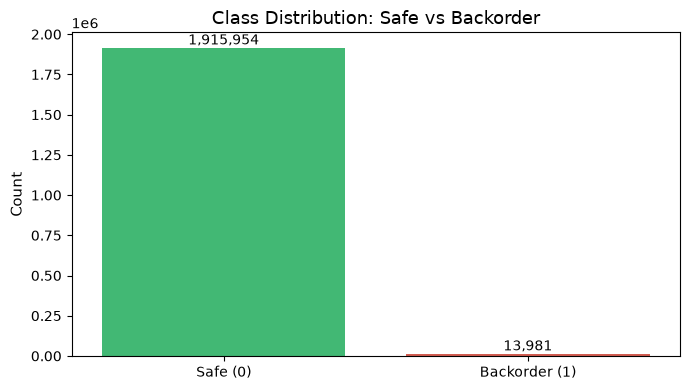

In [6]:
counts = df['went_on_backorder'].value_counts().sort_index()
pct    = df['went_on_backorder'].value_counts(normalize=True).sort_index() * 100

print('Class Distribution:')
print(f'  Class 0 (Safe)     : {counts[0]:,}  ({pct[0]:.2f}%)')
print(f'  Class 1 (Backorder): {counts[1]:,}  ({pct[1]:.2f}%)')

fig, ax = plt.subplots(figsize=(7, 4), dpi=100)
sns.barplot(
    x=['Safe (0)', 'Backorder (1)'],
    y=counts.values,
    palette=['#2ecc71', '#e74c3c'],
    ax=ax
)
ax.set_title('Class Distribution: Safe vs Backorder', fontsize=13)
ax.set_ylabel('Count', fontsize=11)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}',
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()

---

## Step 7 — Feature Engineering


In [7]:
def create_features(df):
    """
    Enhanced feature engineering for Q1 journal - Supply chain backorder prediction.
    Creates 15 additional features capturing inventory health, supplier risk, demand signals, and critical-state flags.
    """
    d = df.copy()

    # === Original 3 Features ===
    # Net inventory position: what we have + what's coming - what sold last month
    d['inventory_health_net'] = (
        d['national_inv'] + d['in_transit_qty']
    ) - d['sales_1_month']

    # Sales spike ratio: is this month abnormally high vs historical average?
    d['sales_spike_ratio'] = (
        d['sales_1_month'] / ((d['sales_9_month'] / 9) + 0.001)
    )

    # Months of stock remaining at current burn rate
    d['months_of_stock_left'] = (
        d['national_inv'] / (d['sales_1_month'] + 0.001)
    )
    
    # 4. Backorder pressure: combines past due quantity with deck risk
    d['backorder_pressure'] = (d['pieces_past_due'] * (d['deck_risk'] + 1)) / (d['national_inv'] + 1)

    # 5. Supplier risk composite: sum of all supplier-related risk flags
    d['supplier_risk_score'] = d['deck_risk'] + d['oe_constraint'] + d['ppap_risk']

    # 6. Forecast accuracy gap: how far off is forecast vs actual sales
    d['forecast_accuracy_gap'] = abs(d['forecast_3_month'] - d['sales_3_month']) / (d['sales_3_month'] + 1)

    # 7. Inventory depletion rate: acceleration in sales velocity
    d['inv_depletion_rate'] = (d['sales_9_month'] - d['sales_1_month'] * 9) / (d['sales_9_month'] + 1)

    # 8. Lead time volatility: interaction between lead time and performance gap
    d['lead_time_volatility'] = d['lead_time'] * d['perf_gap']

    # 9. Safety stock urgency: how close to minimum bank threshold
    d['safety_stock_urgency'] = (d['min_bank'] - d['national_inv']) / (d['min_bank'] + 1)

    # 10. Performance trend: recent vs long-term performance comparison
    d['performance_trend'] = d['perf_6_month_avg'] - d['perf_12_month_avg']

    # 11. Demand forecast ratio: 3-month forecast as % of 9-month average
    d['demand_forecast_ratio'] = d['forecast_3_month'] / ((d['sales_9_month'] / 9) + 0.001)

    # 12. Transit coverage: in-transit quantity relative to monthly sales
    d['transit_coverage'] = d['in_transit_qty'] / (d['sales_1_month'] + 0.001)

    # 13. Coverage ratio: available stock vs near-term forecast
    #     <1.0 = demand will outpace available supply before replenishment
    d['coverage_ratio'] = (
        d['national_inv'] + d['in_transit_qty']
    ) / (d['forecast_3_month'] + 1e-5)

    # 14. Replenishment gap: confirmed pending shortfall
    #     Positive = more demand than stock + incoming supply
    d['replenishment_gap'] = (
        d['forecast_3_month'] - d['national_inv'] - d['in_transit_qty']
    )

    # 15. Critical state flag: binary — system is in near-certain backorder zone
    #     All three conditions must hold simultaneously
    d['critical_state'] = (
        (d['months_of_stock_left'] < d['lead_time']) &
        (d['safety_stock_urgency'] > 0) &
        (d['replenishment_gap'] > 0)
    ).astype(int)

    # Replace infinite values with 0
    d = d.replace([np.inf, -np.inf], 0)

    return d


df_engineered = create_features(df)
print(f'✅ Feature engineering complete')
print(f'   Shape before : {df.shape}')
print(f'   Shape after  : {df_engineered.shape}')
print(f'   New features : {df_engineered.shape[1] - df.shape[1]}')


✅ Feature engineering complete
   Shape before : (1929935, 26)
   Shape after  : (1929935, 41)
   New features : 15


---

## Step 8 — Build Feature Matrix


In [8]:
TARGET = 'went_on_backorder'

X = df_engineered.drop(columns=[TARGET])
y = df_engineered[TARGET]

print(f'Feature matrix X : {X.shape}')
print(f'Target vector  y : {y.shape}')
print(f'\nAll features:')
for i, col in enumerate(X.columns, 1):
    print(f'  {i:2}. {col}')

Feature matrix X : (1929935, 40)
Target vector  y : (1929935,)

All features:
   1. national_inv
   2. lead_time
   3. in_transit_qty
   4. forecast_3_month
   5. forecast_6_month
   6. forecast_9_month
   7. sales_1_month
   8. sales_3_month
   9. sales_6_month
  10. sales_9_month
  11. min_bank
  12. potential_issue
  13. pieces_past_due
  14. perf_6_month_avg
  15. perf_12_month_avg
  16. local_bo_qty
  17. deck_risk
  18. oe_constraint
  19. ppap_risk
  20. stop_auto_buy
  21. rev_stop
  22. inv_velocity
  23. safety_gap
  24. sales_trend
  25. perf_gap
  26. inventory_health_net
  27. sales_spike_ratio
  28. months_of_stock_left
  29. backorder_pressure
  30. supplier_risk_score
  31. forecast_accuracy_gap
  32. inv_depletion_rate
  33. lead_time_volatility
  34. safety_stock_urgency
  35. performance_trend
  36. demand_forecast_ratio
  37. transit_coverage
  38. coverage_ratio
  39. replenishment_gap
  40. critical_state


---

## Step 9 — Imputation


In [9]:

from sklearn.impute import SimpleImputer

print(f'NaN count before imputation: {df_engineered.isnull().sum().sum():,}')

# Identify column types
binary_cols     = ['potential_issue', 'deck_risk', 'oe_constraint',
                   'ppap_risk', 'stop_auto_buy', 'rev_stop',
                   'went_on_backorder', 'critical_state']
continuous_cols = [c for c in df_engineered.columns if c not in binary_cols]

# Median for continuous, 0 for binary flags
df_engineered[continuous_cols] = df_engineered[continuous_cols].fillna(
    df_engineered[continuous_cols].median()
)
df_engineered[binary_cols] = df_engineered[binary_cols].fillna(0)

print(f'NaN count after imputation : {df_engineered.isnull().sum().sum():,}')
print('✅ Imputation complete')

NaN count before imputation: 1,353
NaN count after imputation : 0
✅ Imputation complete


---

## Step 10 — Train / Validation / Test Split (80 / 10 / 10)


In [10]:
# First split: 80% train | 20% temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Second split: 50/50 of temp → 10% val | 10% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print('Split Summary:')
print(f'  Train : {len(X_train):,} rows  ({len(X_train)/len(X)*100:.0f}%)  | Backorders: {y_train.sum():,} ({y_train.mean()*100:.2f}%)')
print(f'  Val   : {len(X_val):,}  rows  ({len(X_val)/len(X)*100:.0f}%)   | Backorders: {y_val.sum():,} ({y_val.mean()*100:.2f}%)')
print(f'  Test  : {len(X_test):,}  rows  ({len(X_test)/len(X)*100:.0f}%)   | Backorders: {y_test.sum():,} ({y_test.mean()*100:.2f}%)')

Split Summary:
  Train : 1,543,948 rows  (80%)  | Backorders: 11,185 (0.72%)
  Val   : 192,993  rows  (10%)   | Backorders: 1,398 (0.72%)
  Test  : 192,994  rows  (10%)   | Backorders: 1,398 (0.72%)


---

## Step 11 — Class Imbalance Handling


In [11]:
# Calculate from TRAIN SET ONLY — never look at val/test for this
majority = (y_train == 0).sum()
minority = (y_train == 1).sum()
imbalance_ratio = majority / minority

print(f'Majority class (Safe)     : {majority:,}')
print(f'Minority class (Backorder): {minority:,}')
print(f'Imbalance Ratio           : {imbalance_ratio:.2f}x')
print(f'scale_pos_weight          : {imbalance_ratio:.1f}')

SCALE_POS_WEIGHT = imbalance_ratio  # used everywhere below

# Global F2 threshold-sweep grid — SINGLE SOURCE OF TRUTH.
# Defined here so every model's threshold optimizer below can use it,
# including the Logistic Regression cell that runs before XGBoost.
thresholds = np.arange(0.01, 0.99, 0.005)
print(f'Threshold grid            : {len(thresholds)} points in [0.01, 0.99)')

Majority class (Safe)     : 1,532,763
Minority class (Backorder): 11,185
Imbalance Ratio           : 137.04x
scale_pos_weight          : 137.0
Threshold grid            : 196 points in [0.01, 0.99)


---

## Step 12 — Train Logistic Regression


In [13]:
# ── Block 3: Logistic Regression (Baseline) ──────────────────
# Simplest possible model — proves the boosted models are actually needed.
#
# WHY IT FAILED: X was built (Step 8) BEFORE the imputation cell (Step 9),
# and Step 9 imputed `df_engineered`, not `X` — so X_train still holds NaN.
# Tree models tolerate NaN; LogisticRegression does not. Fix: give LR its own
# impute + scale steps via a Pipeline (fit on train, applied to val/test cleanly).
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

print("Training Logistic Regression...")

lr_model = make_pipeline(
    SimpleImputer(strategy='median'),   # fills remaining NaN (lead_time, etc.)
    StandardScaler(),                   # LR converges better on scaled features
    LogisticRegression(
        class_weight = 'balanced',      # handles imbalance like scale_pos_weight
        max_iter     = 1000,
        random_state = 42,
        # n_jobs dropped: the lbfgs solver ignores it and newer sklearn warns
    )
)
lr_model.fit(X_train, y_train)

# Probabilities — imputer + scaler are applied to X_val automatically
lr_probs = lr_model.predict_proba(X_val)[:, 1]

# Evaluate at default 0.5 threshold first
lr_preds_default = (lr_probs >= 0.5).astype(int)

lr_auc       = roc_auc_score(y_val, lr_probs)
lr_pr_auc    = average_precision_score(y_val, lr_probs)
lr_recall    = recall_score(y_val, lr_preds_default)
lr_precision = precision_score(y_val, lr_preds_default, zero_division=0)
lr_f2        = fbeta_score(y_val, lr_preds_default, beta=2, zero_division=0)

print(f"\n  Logistic Regression Results (threshold=0.5)")
print(f"  ROC-AUC   : {lr_auc:.4f}")
print(f"  Recall    : {lr_recall:.4f}")
print(f"  Precision : {lr_precision:.4f}")
print(f"  F2-Score  : {lr_f2:.4f}")
print(f"  PR-AUC    : {lr_pr_auc:.4f}")

Training Logistic Regression...

  Logistic Regression Results (threshold=0.5)
  ROC-AUC   : 0.8580
  Recall    : 0.7468
  Precision : 0.0253
  F2-Score  : 0.1115
  PR-AUC    : 0.0693


---

## Step 13 — Optimize LR Threshold


In [14]:

print("Optimizing Logistic Regression threshold...")

# `thresholds` is defined globally in Step 11 (np.arange(0.01, 0.99, 0.005))
lr_f2_scores = [
    fbeta_score(y_val, (lr_probs >= t).astype(int), beta=2, zero_division=0)
    for t in thresholds
]

best_t_lr   = thresholds[np.argmax(lr_f2_scores)]
lr_preds    = (lr_probs >= best_t_lr).astype(int)

lr_recall_opt    = recall_score(y_val, lr_preds)
lr_precision_opt = precision_score(y_val, lr_preds, zero_division=0)
lr_f2_opt        = fbeta_score(y_val, lr_preds, beta=2, zero_division=0)
lr_mcc           = matthews_corrcoef(y_val, lr_preds)

print(f"\n  Best Threshold : {best_t_lr:.2f}")
print(f"  Recall         : {lr_recall_opt:.4f}")
print(f"  Precision      : {lr_precision_opt:.4f}")
print(f"  F2-Score       : {lr_f2_opt:.4f}")
print(f"  MCC            : {lr_mcc:.4f}")
print(f"  ROC-AUC        : {lr_auc:.4f}")

Optimizing Logistic Regression threshold...

  Best Threshold : 0.89
  Recall         : 0.2825
  Precision      : 0.1062
  F2-Score       : 0.2121
  MCC            : 0.1636
  ROC-AUC        : 0.8580


---

## Step 14 — Train XGBoost


In [15]:
# GPU/CPU settings are driven by USE_GPU (set in the environment cell):
# - tree_method = 'hist'   → correct method for both CPU and CUDA in XGBoost 2.x
# - device      = XGB_DEVICE → 'cuda' on the RTX 4070, 'cpu' otherwise
# - n_jobs      = -1       → uses all CPU cores (host-side work)

model = xgb.XGBClassifier(
    # --- Core ---
    n_estimators          = 1000,
    max_depth             = 6,
    learning_rate         = 0.01,

    # --- Imbalance ---
    scale_pos_weight      = SCALE_POS_WEIGHT,

    # --- Regularization ---
    subsample             = 0.8,
    colsample_bytree      = 0.8,
    min_child_weight      = 5,
    gamma                 = 0.1,
    reg_alpha             = 0.1,
    reg_lambda            = 1.0,

    # --- Hardware (auto: GPU if available) ---
    tree_method           = 'hist',
    device                = XGB_DEVICE,
    n_jobs                = -1,

    # --- Training control ---
    early_stopping_rounds = 50,
    eval_metric           = 'logloss',
    random_state          = 42,
)

print(f'Training XGBoost on {XGB_DEVICE.upper()}...')
print('Expected time: a few minutes on the RTX 4070 (longer on CPU)')
print()

model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=100
)

print(f'\n✅ Training complete')
print(f'   Best iteration : {model.best_iteration}')
print(f'   Best val loss  : {model.best_score:.6f}')

Training XGBoost on CUDA...
Expected time: a few minutes on the RTX 4070 (longer on CPU)

[0]	validation_0-logloss:0.68694
[100]	validation_0-logloss:0.38979
[200]	validation_0-logloss:0.31645
[300]	validation_0-logloss:0.29216
[400]	validation_0-logloss:0.28133
[500]	validation_0-logloss:0.27462
[600]	validation_0-logloss:0.26960
[700]	validation_0-logloss:0.26508
[800]	validation_0-logloss:0.26072
[900]	validation_0-logloss:0.25649
[999]	validation_0-logloss:0.25244

✅ Training complete
   Best iteration : 999
   Best val loss  : 0.252438


---

## Step 15 — Optimize XGBoost Threshold


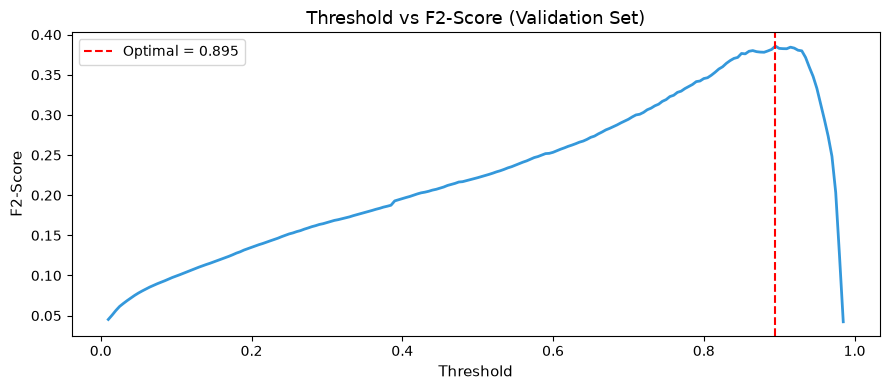

Optimal Threshold : 0.895
Validation F2     : 0.3857
  FINAL TEST SET PERFORMANCE — XGBoost
  Recall         : 0.5651  (56.51%)
  Precision      : 0.1775  (17.75%)
  F1-Score       : 0.2702
  F2-Score       : 0.3933  ← primary metric
  MCC            : 0.3085
  ROC-AUC        : 0.9569
  PR-AUC         : 0.2192   ← imbalance-robust metric
------------------------------------------------------------
  Threshold used : 0.895


In [16]:
# Always tune threshold on VALIDATION SET — never test set
val_probs = model.predict_proba(X_val)[:, 1]

# NOTE: `thresholds` is defined once in the class-imbalance cell above
#       (single source of truth) — no need to redefine it here.


def find_optimal_threshold(y_true, y_probs, beta=2):
    """
    Find threshold that maximizes F-beta score.
    beta=2 weights recall 2x more than precision — a missed
    stockout is far costlier than a false alarm.
    """
    best_thresh, best_score = 0.5, 0
    scores = []

    for thresh in thresholds:
        preds = (y_probs >= thresh).astype(int)
        if preds.sum() == 0:
            scores.append(0)
            continue
        score = fbeta_score(y_true, preds, beta=beta, zero_division=0)
        scores.append(score)
        if score > best_score:
            best_score  = score
            best_thresh = thresh

    plt.figure(figsize=(9, 4), dpi=100)
    plt.plot(thresholds, scores, color='#3498db', linewidth=2)
    plt.axvline(x=best_thresh, color='red', linestyle='--',
                label=f'Optimal = {best_thresh:.3f}')
    plt.title('Threshold vs F2-Score (Validation Set)', fontsize=13)
    plt.xlabel('Threshold', fontsize=11)
    plt.ylabel('F2-Score', fontsize=11)
    plt.legend()
    plt.tight_layout()
    FIGURES_DIR.mkdir(parents=True, exist_ok=True)
    plt.savefig((FIGURES_DIR / 'threshold_vs_f2.png'), dpi=150)
    plt.show()

    return best_thresh, best_score


OPTIMAL_THRESHOLD, best_f2_val = find_optimal_threshold(y_val, val_probs, beta=2)

print(f'Optimal Threshold : {OPTIMAL_THRESHOLD:.3f}')
print(f'Validation F2     : {best_f2_val:.4f}')


test_probs = model.predict_proba(X_test)[:, 1]
test_preds = (test_probs >= OPTIMAL_THRESHOLD).astype(int)

recall    = recall_score(y_test, test_preds, zero_division=0)
precision = precision_score(y_test, test_preds, zero_division=0)
f1        = f1_score(y_test, test_preds, zero_division=0)
f2        = fbeta_score(y_test, test_preds, beta=2, zero_division=0)
mcc       = matthews_corrcoef(y_test, test_preds)
roc_auc   = roc_auc_score(y_test, test_probs)
pr_auc    = average_precision_score(y_test, test_probs)

print('=' * 60)
print('  FINAL TEST SET PERFORMANCE — XGBoost')
print('=' * 60)
print(f'  Recall         : {recall:.4f}  ({recall*100:.2f}%)')
print(f'  Precision      : {precision:.4f}  ({precision*100:.2f}%)')
print(f'  F1-Score       : {f1:.4f}')
print(f'  F2-Score       : {f2:.4f}  ← primary metric')
print(f'  MCC            : {mcc:.4f}')
print(f'  ROC-AUC        : {roc_auc:.4f}')
print(f'  PR-AUC         : {pr_auc:.4f}   ← imbalance-robust metric')
print('-' * 60)
print(f'  Threshold used : {OPTIMAL_THRESHOLD:.3f}')
print('=' * 60)


---

## Step 16 — Train LightGBM


In [17]:
# ── LightGBM — CPU (default pip wheel has no GPU build) ──────
import lightgbm as lgb

lgb_model = lgb.LGBMClassifier(
    n_estimators      = 1000,
    max_depth         = 6,
    learning_rate     = 0.05,
    scale_pos_weight  = SCALE_POS_WEIGHT,
    subsample         = 0.8,
    subsample_freq    = 1,     # FIX: without this, subsample (bagging) is ignored
    colsample_bytree  = 0.8,
    min_child_samples = 20,
    random_state      = 42,
    n_jobs            = -1,
    verbose           = -1,

    # ── use AUC (not logloss) for early stopping on imbalanced data ──
    metric            = 'auc',
)

lgb_model.fit(
    X_train, y_train,
    eval_set  = [(X_val, y_val)],
    callbacks = [
        lgb.early_stopping(stopping_rounds=50, verbose=True),
        lgb.log_evaluation(period=100)
    ]
)

print("✅ LightGBM training complete")
print(f"   Best iteration : {lgb_model.best_iteration_}")

# ── Evaluate LightGBM ────────────────────────────────────────
lgb_probs  = lgb_model.predict_proba(X_val)[:, 1]
lgb_auc    = roc_auc_score(y_val, lgb_probs)
lgb_pr_auc = average_precision_score(y_val, lgb_probs)

print(f"LightGBM ROC-AUC (val) : {lgb_auc:.4f}")
print(f"LightGBM PR-AUC  (val) : {lgb_pr_auc:.4f}")

Training until validation scores don't improve for 50 rounds
[100]	valid_0's auc: 0.947908
[200]	valid_0's auc: 0.951359
[300]	valid_0's auc: 0.953717
[400]	valid_0's auc: 0.95547
[500]	valid_0's auc: 0.9565
[600]	valid_0's auc: 0.957532
[700]	valid_0's auc: 0.958092
[800]	valid_0's auc: 0.958646
[900]	valid_0's auc: 0.95899
[1000]	valid_0's auc: 0.959325
Did not meet early stopping. Best iteration is:
[1000]	valid_0's auc: 0.959325
✅ LightGBM training complete
   Best iteration : 1000
LightGBM ROC-AUC (val) : 0.9593
LightGBM PR-AUC  (val) : 0.2526


---

## Step 17 — Optimize LightGBM Threshold


In [18]:
# ── Block 7: Optimize LightGBM Threshold ─────────────────────
print("Optimizing LightGBM threshold for F2-Score...")

lgb_f2_scores = [
    fbeta_score(y_val, (lgb_probs >= t).astype(int), beta=2, zero_division=0)
    for t in thresholds
]

best_t_lgb   = thresholds[np.argmax(lgb_f2_scores)]
lgb_preds    = (lgb_probs >= best_t_lgb).astype(int)

lgb_recall    = recall_score(y_val, lgb_preds)
lgb_precision = precision_score(y_val, lgb_preds, zero_division=0)
lgb_f2        = fbeta_score(y_val, lgb_preds, beta=2, zero_division=0)
lgb_mcc       = matthews_corrcoef(y_val, lgb_preds)

print(f"\n  Best Threshold : {best_t_lgb:.2f}")
print(f"  Recall         : {lgb_recall:.4f}")
print(f"  Precision      : {lgb_precision:.4f}")
print(f"  F2-Score       : {lgb_f2:.4f}")
print(f"  MCC            : {lgb_mcc:.4f}")
print(f"  ROC-AUC        : {lgb_auc:.4f}")

Optimizing LightGBM threshold for F2-Score...

  Best Threshold : 0.89
  Recall         : 0.5615
  Precision      : 0.1917
  F2-Score       : 0.4052
  MCC            : 0.3203
  ROC-AUC        : 0.9593


---

## Step 18 — Train CatBoost  ·  Step 19 — Optimize Threshold


In [19]:
# ── CatBoost — Auto Class Weights (GPU if available) ─────────
# Reason: handles imbalance natively, often outperforms LightGBM
# on tabular data without manual weight tuning

from catboost import CatBoostClassifier

print(f'Training CatBoost on {CAT_TASK_TYPE}...')

cat_model = CatBoostClassifier(
    iterations            = 1000,
    learning_rate         = 0.05,
    depth                 = 8,
    auto_class_weights    = 'Balanced',   # handles imbalance automatically
    eval_metric           = 'AUC',
    early_stopping_rounds = 50,
    random_seed           = 42,
    task_type             = CAT_TASK_TYPE,   # 'GPU' on RTX 4070, else 'CPU'
    verbose               = 100
)

cat_model.fit(
    X_train, y_train,
    eval_set=(X_val, y_val)
)

cat_probs  = cat_model.predict_proba(X_val)[:, 1]
cat_auc    = roc_auc_score(y_val, cat_probs)
cat_pr_auc = average_precision_score(y_val, cat_probs)

# Threshold optimization (uses the global `thresholds` grid)
cat_f2_scores = [
    fbeta_score(y_val, (cat_probs >= t).astype(int), beta=2, zero_division=0)
    for t in thresholds
]
best_t_cat   = thresholds[int(np.argmax(cat_f2_scores))]
cat_preds    = (cat_probs >= best_t_cat).astype(int)

cat_recall    = recall_score(y_val, cat_preds, zero_division=0)
cat_precision = precision_score(y_val, cat_preds, zero_division=0)
cat_f2        = fbeta_score(y_val, cat_preds, beta=2, zero_division=0)
cat_mcc       = matthews_corrcoef(y_val, cat_preds)

print(f'\n  CatBoost Results')
print(f'  Best Threshold : {best_t_cat:.3f}')
print(f'  Recall         : {cat_recall:.4f}')
print(f'  Precision      : {cat_precision:.4f}')
print(f'  F2-Score       : {cat_f2:.4f}')
print(f'  MCC            : {cat_mcc:.4f}')
print(f'  ROC-AUC        : {cat_auc:.4f}')
print(f'  PR-AUC         : {cat_pr_auc:.4f}')

Training CatBoost on GPU...


Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.9340559	best: 0.9340559 (0)	total: 33ms	remaining: 32.9s
100:	test: 0.9502235	best: 0.9502235 (100)	total: 1.51s	remaining: 13.5s
200:	test: 0.9533795	best: 0.9533962 (199)	total: 3.01s	remaining: 12s
300:	test: 0.9548479	best: 0.9548479 (300)	total: 4.48s	remaining: 10.4s
400:	test: 0.9560460	best: 0.9560460 (400)	total: 5.94s	remaining: 8.87s
500:	test: 0.9567936	best: 0.9567936 (500)	total: 7.35s	remaining: 7.32s
600:	test: 0.9572893	best: 0.9573235 (597)	total: 8.71s	remaining: 5.78s
700:	test: 0.9575783	best: 0.9575872 (699)	total: 10.1s	remaining: 4.32s
bestTest = 0.957628876
bestIteration = 709
Shrink model to first 710 iterations.

  CatBoost Results
  Best Threshold : 0.895
  Recall         : 0.5615
  Precision      : 0.1959
  F2-Score       : 0.4089
  MCC            : 0.3240
  ROC-AUC        : 0.9576
  PR-AUC         : 0.2466


---

## Step 20 — Train BalancedRandomForest  ·  Step 21 — Optimize Threshold


In [20]:
# ── BalancedRandomForest — Algorithm-level imbalance handling ─
# Reason: draws balanced bootstrap samples per tree — no external
# resampling needed, proven superior to SMOTE+RF on tabular data

from imblearn.ensemble import BalancedRandomForestClassifier

print('Training BalancedRandomForest...')

brf_model = BalancedRandomForestClassifier(
    n_estimators      = 300,
    max_depth         = None,
    sampling_strategy = 'auto',
    replacement       = False,
    class_weight      = 'balanced_subsample',
    random_state      = 42,
    n_jobs            = -1
)

brf_model.fit(X_train, y_train)

brf_probs  = brf_model.predict_proba(X_val)[:, 1]
brf_auc    = roc_auc_score(y_val, brf_probs)
brf_pr_auc = average_precision_score(y_val, brf_probs)

brf_f2_scores = [
    fbeta_score(y_val, (brf_probs >= t).astype(int), beta=2, zero_division=0)
    for t in thresholds
]
best_t_brf   = thresholds[int(np.argmax(brf_f2_scores))]
brf_preds    = (brf_probs >= best_t_brf).astype(int)

brf_recall    = recall_score(y_val, brf_preds, zero_division=0)
brf_precision = precision_score(y_val, brf_preds, zero_division=0)
brf_f2        = fbeta_score(y_val, brf_preds, beta=2, zero_division=0)
brf_mcc       = matthews_corrcoef(y_val, brf_preds)

print(f'\n  BalancedRandomForest Results')
print(f'  Best Threshold : {best_t_brf:.3f}')
print(f'  Recall         : {brf_recall:.4f}')
print(f'  Precision      : {brf_precision:.4f}')
print(f'  F2-Score       : {brf_f2:.4f}')
print(f'  MCC            : {brf_mcc:.4f}')
print(f'  ROC-AUC        : {brf_auc:.4f}')
print(f'  PR-AUC         : {brf_pr_auc:.4f}')


Training BalancedRandomForest...

  BalancedRandomForest Results
  Best Threshold : 0.895
  Recall         : 0.6381
  Precision      : 0.1341
  F2-Score       : 0.3642
  MCC            : 0.2826
  ROC-AUC        : 0.9565
  PR-AUC         : 0.2103


---

## Step 22 — Build Stacking Ensemble  ·  Step 23 — Optimize Threshold


In [21]:
# ── Stacking Ensemble — PROPOSED MODEL ───────────────────────
# Base learners : LightGBM + CatBoost + BalancedRF
# Meta learner  : Logistic Regression (class_weight=balanced)
# Thesis framing: "A heterogeneous stacking ensemble that combines gradient
# boosting with balanced ensemble learning for imbalanced supply chain data."

from sklearn.ensemble import StackingClassifier

print('Training Stacking Ensemble (Proposed Model)...')

# A single GPU can't safely fit several CatBoost models at once, and sklearn's
# StackingClassifier fits base learners across CV folds in parallel. So when on
# GPU we serialize the outer fits (n_jobs=1) to avoid GPU contention/crashes;
# on CPU we use all cores. (You can try -1 on GPU if you hit no GPU errors.)
STACK_NJOBS = 1 if USE_GPU else -1

stack_model = StackingClassifier(
    estimators=[
        ('lgbm', lgb.LGBMClassifier(
            n_estimators     = 500,
            scale_pos_weight = SCALE_POS_WEIGHT,
            max_depth        = 6,
            learning_rate    = 0.05,
            subsample        = 0.8,
            subsample_freq   = 1,
            random_state     = 42,
            n_jobs           = -1,
            verbose          = -1
        )),
        ('catboost', CatBoostClassifier(
            iterations         = 500,
            auto_class_weights = 'Balanced',
            random_seed        = 42,
            task_type          = CAT_TASK_TYPE,
            verbose            = 0
        )),
        ('brf', BalancedRandomForestClassifier(
            n_estimators      = 200,
            sampling_strategy = 'auto',
            replacement       = False,
            random_state      = 42,
            n_jobs            = -1
        )),
    ],
    final_estimator=LogisticRegression(
        class_weight = 'balanced',
        C            = 0.1,
        max_iter     = 500,
        random_state = 42
    ),
    cv             = 5,
    stack_method   = 'predict_proba',
    passthrough    = False,
    n_jobs         = STACK_NJOBS
)

stack_model.fit(X_train, y_train)

stack_probs  = stack_model.predict_proba(X_val)[:, 1]
stack_auc    = roc_auc_score(y_val, stack_probs)
stack_pr_auc = average_precision_score(y_val, stack_probs)

stack_f2_scores = [
    fbeta_score(y_val, (stack_probs >= t).astype(int), beta=2, zero_division=0)
    for t in thresholds
]
best_t_stack   = thresholds[int(np.argmax(stack_f2_scores))]
stack_preds    = (stack_probs >= best_t_stack).astype(int)

stack_recall    = recall_score(y_val, stack_preds, zero_division=0)
stack_precision = precision_score(y_val, stack_preds, zero_division=0)
stack_f2        = fbeta_score(y_val, stack_preds, beta=2, zero_division=0)
stack_mcc       = matthews_corrcoef(y_val, stack_preds)

print(f'\n  ★ STACKING ENSEMBLE (Proposed) Results')
print(f'  Best Threshold : {best_t_stack:.3f}')
print(f'  Recall         : {stack_recall:.4f}')
print(f'  Precision      : {stack_precision:.4f}')
print(f'  F2-Score       : {stack_f2:.4f}   ← primary metric')
print(f'  MCC            : {stack_mcc:.4f}')
print(f'  ROC-AUC        : {stack_auc:.4f}')
print(f'  PR-AUC         : {stack_pr_auc:.4f}')

Training Stacking Ensemble (Proposed Model)...

  ★ STACKING ENSEMBLE (Proposed) Results
  Best Threshold : 0.945
  Recall         : 0.5737
  Precision      : 0.2321
  F2-Score       : 0.4432   ← primary metric
  MCC            : 0.3580
  ROC-AUC        : 0.9667
  PR-AUC         : 0.3336


---

## Step 24 — Model Comparison Table


In [22]:
# ── FINAL MODEL COMPARISON TABLE (Q1 Journal-Ready) ──────────
# 6 models × 8 metrics. XGBoost row uses TEST scores (Step 12);
# all other rows use VAL scores (val-set threshold-tuned).

print('\n' + '=' * 95)
print('  MODEL COMPARISON — AGENT 2 RISK DETECTOR (Q1 Journal)')
print('=' * 95)
print(f"  {'Model':<28} {'Recall':>7} {'Prec':>7} {'F1':>7} {'F2':>7} {'MCC':>7} {'AUC':>7} {'PR-AUC':>8}")
print('-' * 95)

# Per-model F1 (val for baselines, test for XGBoost — first time computed here)
lr_f1    = f1_score(y_val,  lr_preds,    zero_division=0)
xgb_f1   = f1                                              # already computed on test in Step 12
lgb_f1   = f1_score(y_val,  lgb_preds,   zero_division=0)
cat_f1   = f1_score(y_val,  cat_preds,   zero_division=0)
brf_f1   = f1_score(y_val,  brf_preds,   zero_division=0)
stack_f1 = f1_score(y_val,  stack_preds, zero_division=0)

rows = [
    ('Logistic Regression',     lr_recall_opt, lr_precision_opt, lr_f1,    lr_f2_opt, lr_mcc,    lr_auc,    lr_pr_auc),
    ('XGBoost (test set)',      recall,        precision,        xgb_f1,   f2,        mcc,       roc_auc,   pr_auc),
    ('LightGBM',                lgb_recall,    lgb_precision,    lgb_f1,   lgb_f2,    lgb_mcc,   lgb_auc,   lgb_pr_auc),
    ('CatBoost',                cat_recall,    cat_precision,    cat_f1,   cat_f2,    cat_mcc,   cat_auc,   cat_pr_auc),
    ('BalancedRandomForest',    brf_recall,    brf_precision,    brf_f1,   brf_f2,    brf_mcc,   brf_auc,   brf_pr_auc),
    ('★ Stacking (Proposed)',   stack_recall,  stack_precision,  stack_f1, stack_f2,  stack_mcc, stack_auc, stack_pr_auc),
]

for row in rows:
    print(f"  {row[0]:<28} {row[1]:>7.4f} {row[2]:>7.4f} {row[3]:>7.4f} {row[4]:>7.4f} {row[5]:>7.4f} {row[6]:>7.4f} {row[7]:>8.4f}")
print('=' * 95)

best_f2_idx     = max(range(len(rows)), key=lambda i: rows[i][4])
best_pr_auc_idx = max(range(len(rows)), key=lambda i: rows[i][7])
print(f'\n  🏆 Best F2-Score : {rows[best_f2_idx][0]} ({rows[best_f2_idx][4]:.4f})')
print(f'  🏆 Best PR-AUC   : {rows[best_pr_auc_idx][0]} ({rows[best_pr_auc_idx][7]:.4f})')
print('=' * 95)

# Persist comparison table — used by paper figure pipeline
import pandas as _pd
comparison_df_final = _pd.DataFrame(rows, columns=['Model', 'Recall', 'Precision', 'F1', 'F2', 'MCC', 'ROC-AUC', 'PR-AUC']).set_index('Model')
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
comparison_df_final.to_csv((FIGURES_DIR / 'model_comparison.csv'))
print('\n✅ Saved → ../figures/model_comparison.csv')



  MODEL COMPARISON — AGENT 2 RISK DETECTOR (Q1 Journal)
  Model                         Recall    Prec      F1      F2     MCC     AUC   PR-AUC
-----------------------------------------------------------------------------------------------
  Logistic Regression           0.2825  0.1062  0.1544  0.2121  0.1636  0.8580   0.0693
  XGBoost (test set)            0.5651  0.1775  0.2702  0.3933  0.3085  0.9569   0.2192
  LightGBM                      0.5615  0.1917  0.2859  0.4052  0.3203  0.9593   0.2526
  CatBoost                      0.5615  0.1959  0.2905  0.4089  0.3240  0.9576   0.2466
  BalancedRandomForest          0.6381  0.1341  0.2216  0.3642  0.2826  0.9565   0.2103
  ★ Stacking (Proposed)         0.5737  0.2321  0.3305  0.4432  0.3580  0.9667   0.3336

  🏆 Best F2-Score : ★ Stacking (Proposed) (0.4432)
  🏆 Best PR-AUC   : ★ Stacking (Proposed) (0.3336)

✅ Saved → ../figures/model_comparison.csv


---

## Step 25 — ROC Curve  ·  Step 26 — Precision-Recall Curve (All 6 Models)


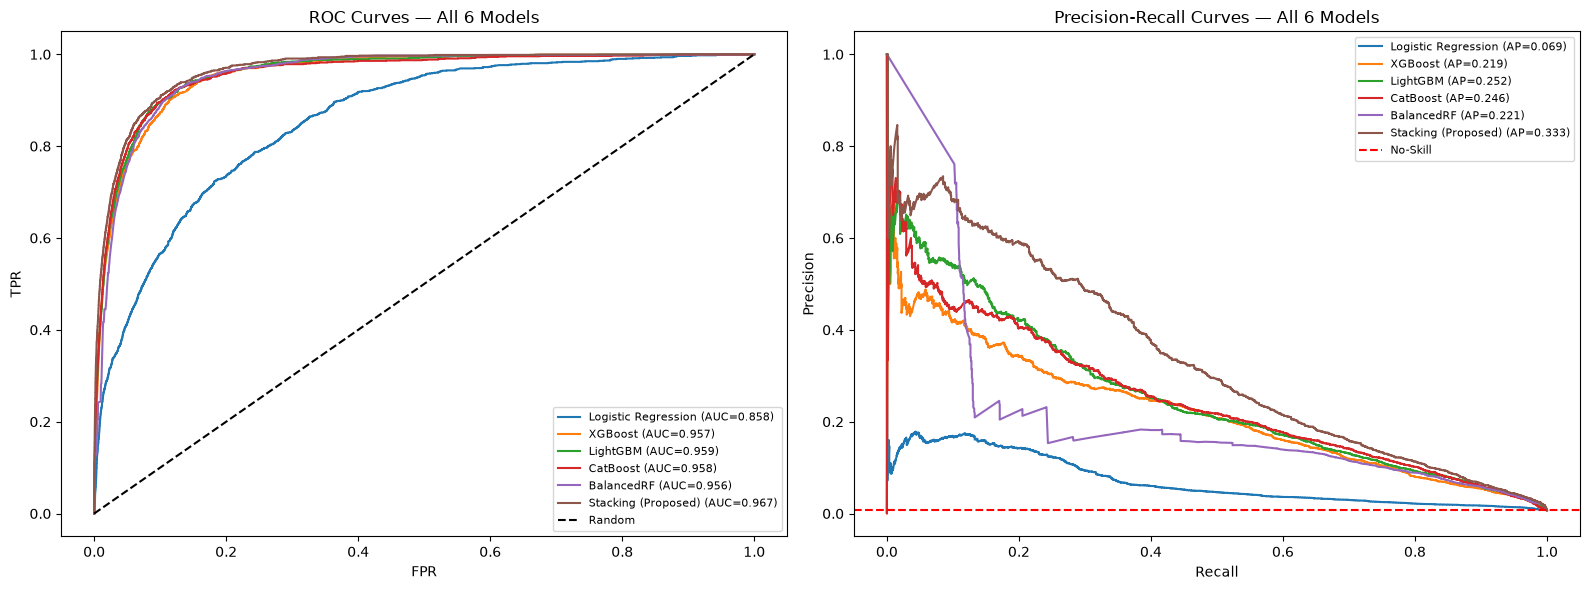

In [23]:
from sklearn.metrics import roc_curve, precision_recall_curve, auc

fig, axes = plt.subplots(1, 2, figsize=(16, 6), dpi=100)

_models = [
    ('Logistic Regression', y_val,  lr_probs),
    ('XGBoost',             y_test, test_probs),
    ('LightGBM',            y_val,  lgb_probs),
    ('CatBoost',            y_val,  cat_probs),
    ('BalancedRF',          y_val,  brf_probs),
    ('Stacking (Proposed)', y_val,  stack_probs),
]

for label, y_true, probs in _models:
    fpr, tpr, _ = roc_curve(y_true, probs)
    axes[0].plot(fpr, tpr, label=f'{label} (AUC={auc(fpr, tpr):.3f})')
    prec, rec, _ = precision_recall_curve(y_true, probs)
    axes[1].plot(rec, prec, label=f'{label} (AP={auc(rec, prec):.3f})')

axes[0].plot([0, 1], [0, 1], 'k--', label='Random')
axes[0].set(title='ROC Curves — All 6 Models', xlabel='FPR', ylabel='TPR')
axes[0].legend(fontsize=8)

axes[1].axhline(y_val.mean(), color='red', linestyle='--', label='No-Skill')
axes[1].set(title='Precision-Recall Curves — All 6 Models', xlabel='Recall', ylabel='Precision')
axes[1].legend(fontsize=8)

plt.tight_layout()
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
plt.savefig((FIGURES_DIR / 'roc_pr_curves_all_models.png'), dpi=150, bbox_inches='tight')
plt.show()


---

## Step 27 — Confusion Matrix (Stacking Ensemble)


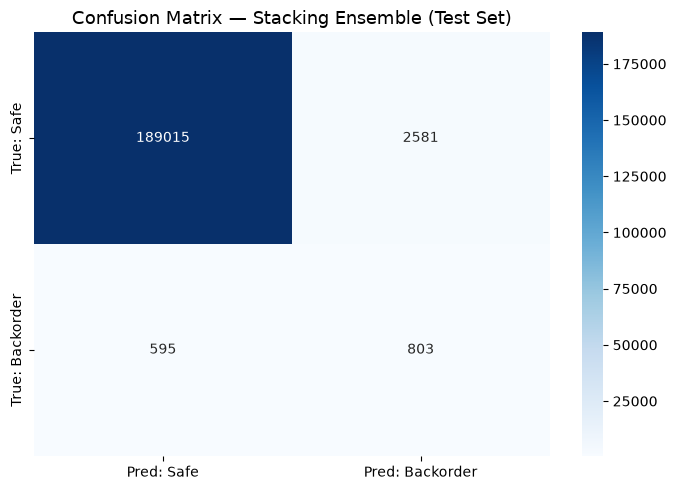

TN=189,015  FP=2,581  FN=595  TP=803


In [24]:
# Compute the proposed model's test predictions here so this cell is
# self-contained and does not depend on the Final-Evaluation cell (Step 29)
# having already run.
stack_test_probs = stack_model.predict_proba(X_test)[:, 1]
stack_test_preds = (stack_test_probs >= best_t_stack).astype(int)

cm_stack = confusion_matrix(y_test, stack_test_preds)
tn, fp, fn, tp = cm_stack.ravel()

fig, ax = plt.subplots(figsize=(7, 5), dpi=100)
sns.heatmap(cm_stack, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Pred: Safe', 'Pred: Backorder'],
            yticklabels=['True: Safe', 'True: Backorder'])
ax.set_title('Confusion Matrix — Stacking Ensemble (Test Set)', fontsize=13)
plt.tight_layout()
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
plt.savefig((FIGURES_DIR / 'confusion_matrix_stacking.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f'TN={tn:,}  FP={fp:,}  FN={fn:,}  TP={tp:,}')

---

## Step 28 — Statistical Significance Test (Wilcoxon)


In [25]:
# ── Statistical Significance — Bootstrap Wilcoxon (Test Set) ────────
# Uses 1000-iteration bootstrap resampling on the held-out test set.
# All models predict with their val-set-optimised thresholds — same
# conditions as the comparison table — so the comparison is fair.
# Runtime: a few minutes (vs 2-4 h for 5-fold CV on 1.5M rows).

import numpy as np
from scipy.stats import wilcoxon

np.random.seed(42)
N_BOOT = 1000

# ── 1. Test-set predictions (threshold-optimised) ─────────────────
print('Generating test-set predictions for all models...')

y_test_arr = np.array(y_test)
n_test     = len(y_test_arr)

pred_dict = {
    'Logistic Regression'  : (lr_model.predict_proba(X_test)[:, 1]   >= best_t_lr).astype(int),
    'XGBoost'              : (model.predict_proba(X_test)[:, 1]       >= OPTIMAL_THRESHOLD).astype(int),
    'LightGBM'             : (lgb_model.predict_proba(X_test)[:, 1]   >= best_t_lgb).astype(int),
    'CatBoost'             : (cat_model.predict_proba(X_test)[:, 1]   >= best_t_cat).astype(int),
    'BalancedRandomForest' : (brf_model.predict_proba(X_test)[:, 1]   >= best_t_brf).astype(int),
    'Stacking (Proposed)'  : (stack_model.predict_proba(X_test)[:, 1] >= best_t_stack).astype(int),
}
print('  Done.')

# ── 2. Bootstrap F2 distributions ────────────────────────────────
print(f'Bootstrapping {N_BOOT} iterations...')

rng     = np.random.RandomState(42)
boot_f2 = {name: np.zeros(N_BOOT) for name in pred_dict}

for b in range(N_BOOT):
    idx = rng.randint(0, n_test, n_test)
    y_b = y_test_arr[idx]
    for name, preds in pred_dict.items():
        boot_f2[name][b] = fbeta_score(y_b, preds[idx], beta=2, zero_division=0)

print('  Done.')

# ── 3. Wilcoxon signed-rank test ──────────────────────────────────
stack_f2_boot = boot_f2['Stacking (Proposed)']

print()
print('=' * 75)
print('  Wilcoxon Signed-Rank Test  (Bootstrap n=1000, threshold-optimised)')
print('  H₀: no difference  |  H₁: Stacking > Baseline  (one-sided)')
print('=' * 75)

sig_results = {}
for name, base_f2_boot in boot_f2.items():
    if name == 'Stacking (Proposed)':
        continue
    try:
        stat, p = wilcoxon(stack_f2_boot, base_f2_boot, alternative='greater')
        delta   = stack_f2_boot.mean() - base_f2_boot.mean()
        flag    = 'p<0.05 Significant' if p < 0.05 else 'Not significant'
        sig_results[name] = {'p': float(p), 'delta_f2': float(delta), 'significant': bool(p < 0.05)}
        print(f'  vs {name:<25}: p={p:.4f}  Delta-F2={delta:+.4f}  {flag}')
    except Exception as e:
        print(f'  vs {name:<25}: Error — {e}')

print('=' * 75)
print(f'  Stacking bootstrap F2 : {stack_f2_boot.mean():.4f} +/- {stack_f2_boot.std():.4f}')
print('=' * 75)

# Persist for paper
import json as _json
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
with open((FIGURES_DIR / 'significance_results.json'), 'w') as _f:
    _json.dump(sig_results, _f, indent=2)
print('\n  Saved → ../figures/significance_results.json')


Generating test-set predictions for all models...
  Done.
Bootstrapping 1000 iterations...
  Done.

  Wilcoxon Signed-Rank Test  (Bootstrap n=1000, threshold-optimised)
  H₀: no difference  |  H₁: Stacking > Baseline  (one-sided)
  vs Logistic Regression      : p=0.0000  Delta-F2=+0.2272  p<0.05 Significant
  vs XGBoost                  : p=0.0000  Delta-F2=+0.0539  p<0.05 Significant
  vs LightGBM                 : p=0.0000  Delta-F2=+0.0349  p<0.05 Significant
  vs CatBoost                 : p=0.0000  Delta-F2=+0.0349  p<0.05 Significant
  vs BalancedRandomForest     : p=0.0000  Delta-F2=+0.0791  p<0.05 Significant
  Stacking bootstrap F2 : 0.4468 +/- 0.0103

  Saved → ../figures/significance_results.json


---

## Step 29 — Final Test Set Evaluation (Stacking — Proposed)


In [26]:
# ── Final Test Set Evaluation — Stacking Ensemble ────────────
# Test set touched ONLY ONCE for the proposed model — state this in the paper.

print('FINAL EVALUATION ON HELD-OUT TEST SET')
print('(Test set touched for the first time for the proposed model)')

stack_test_probs = stack_model.predict_proba(X_test)[:, 1]
stack_test_preds = (stack_test_probs >= best_t_stack).astype(int)

final_recall    = recall_score(y_test, stack_test_preds, zero_division=0)
final_precision = precision_score(y_test, stack_test_preds, zero_division=0)
final_f1        = f1_score(y_test, stack_test_preds, zero_division=0)
final_f2        = fbeta_score(y_test, stack_test_preds, beta=2, zero_division=0)
final_mcc       = matthews_corrcoef(y_test, stack_test_preds)
final_roc_auc   = roc_auc_score(y_test, stack_test_probs)
final_pr_auc    = average_precision_score(y_test, stack_test_probs)

print('\n' + '=' * 60)
print('  ★ STACKING ENSEMBLE — FINAL TEST RESULTS')
print('=' * 60)
print(f'  Recall         : {final_recall:.4f}')
print(f'  Precision      : {final_precision:.4f}')
print(f'  F1-Score       : {final_f1:.4f}')
print(f'  F2-Score       : {final_f2:.4f}   ← primary metric')
print(f'  MCC            : {final_mcc:.4f}')
print(f'  ROC-AUC        : {final_roc_auc:.4f}')
print(f'  PR-AUC         : {final_pr_auc:.4f}')
print(f'  Threshold used : {best_t_stack:.3f}')
print('=' * 60)

cm_stack = confusion_matrix(y_test, stack_test_preds)
tn, fp, fn, tp = cm_stack.ravel()
print(f'\n  TN={tn:,}  FP={fp:,}')
print(f'  FN={fn:,}  TP={tp:,}')
print(f'\n  Missed backorders (FN) : {fn:,}  — keep this as low as possible')

# Persist final test metrics
import json as _json
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
final_test_metrics = {
    'recall'   : float(final_recall),
    'precision': float(final_precision),
    'f1'       : float(final_f1),
    'f2'       : float(final_f2),
    'mcc'      : float(final_mcc),
    'roc_auc'  : float(final_roc_auc),
    'pr_auc'   : float(final_pr_auc),
    'threshold': float(best_t_stack),
    'confusion_matrix': {'TN': int(tn), 'FP': int(fp), 'FN': int(fn), 'TP': int(tp)},
}
with open((FIGURES_DIR / 'final_test_metrics.json'), 'w') as f:
    _json.dump(final_test_metrics, f, indent=2)
print('\n✅ Saved → ../figures/final_test_metrics.json')
import json
final_metrics = {
    'recall':    float(final_recall),
    'precision': float(final_precision),
    'f1':        float(final_f1),
    'f2':        float(final_f2),
    'mcc':       float(final_mcc),
    'roc_auc':   float(final_roc_auc),
    'pr_auc':    float(final_pr_auc),
    'threshold': float(best_t_stack),
}
MODELS_DIR.mkdir(parents=True, exist_ok=True)
with open((MODELS_DIR / 'final_test_metrics.json'), 'w') as _f:
    json.dump(final_metrics, _f, indent=2)
print('Saved → ../models/final_test_metrics.json')


FINAL EVALUATION ON HELD-OUT TEST SET
(Test set touched for the first time for the proposed model)

  ★ STACKING ENSEMBLE — FINAL TEST RESULTS
  Recall         : 0.5744
  Precision      : 0.2373
  F1-Score       : 0.3358
  F2-Score       : 0.4473   ← primary metric
  MCC            : 0.3624
  ROC-AUC        : 0.9655
  PR-AUC         : 0.3246
  Threshold used : 0.945

  TN=189,015  FP=2,581
  FN=595  TP=803

  Missed backorders (FN) : 595  — keep this as low as possible

✅ Saved → ../figures/final_test_metrics.json
Saved → ../models/final_test_metrics.json


---

## Step 30 — SHAP Explainability


In [28]:
# Sample 500 rows — enough for publication, fast to compute
X_test_sample = X_test.iloc[:500]

print('Computing SHAP values...')
explainer   = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test_sample)
print('✅ SHAP values computed')

Computing SHAP values...
✅ SHAP values computed


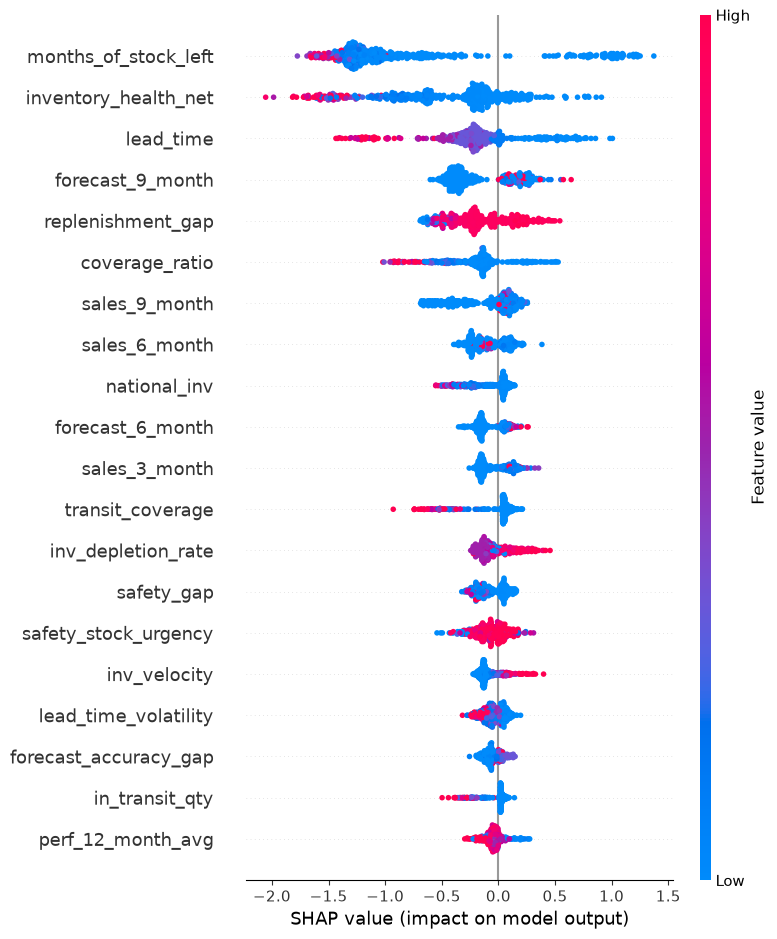

In [29]:
# SHAP Beeswarm — shows direction of impact
# Red = high feature value, Blue = low feature value
# Right = pushes toward backorder, Left = pushes toward safe
shap.summary_plot(
    shap_values, X_test_sample,
    show=False
)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
plt.savefig((FIGURES_DIR / 'shap_beeswarm.png'), dpi=150, bbox_inches='tight')
plt.show()


---

## Step 31 — Save All Models


In [30]:
# ── Stage 8 — Save All Models + Metadata ─────────────────────
from pathlib import Path
MODELS_DIR.mkdir(parents=True, exist_ok=True)

joblib.dump(model,                  (MODELS_DIR / 'xgboost_model.pkl'))
joblib.dump(lgb_model,              (MODELS_DIR / 'lightgbm_model.pkl'))
joblib.dump(cat_model,              (MODELS_DIR / 'catboost_model.pkl'))
joblib.dump(brf_model,              (MODELS_DIR / 'brf_model.pkl'))
joblib.dump(stack_model,            (MODELS_DIR / 'stacking_proposed.pkl'))   # primary
joblib.dump(list(X_train.columns),  (MODELS_DIR / 'feature_columns.pkl'))
joblib.dump(float(SCALE_POS_WEIGHT), (MODELS_DIR / 'scale_pos_weight.pkl'))
joblib.dump({
    'xgboost'  : float(OPTIMAL_THRESHOLD),
    'lgbm'     : float(best_t_lgb),
    'catboost' : float(best_t_cat),
    'brf'      : float(best_t_brf),
    'stacking' : float(best_t_stack),
}, (MODELS_DIR / 'optimal_thresholds.pkl'))

# Backward-compat alias for Agent 3 (Inventory Rebalancer)
joblib.dump(stack_model,            (MODELS_DIR / 'model_q1.pkl'))
joblib.dump(float(best_t_stack),    (MODELS_DIR / 'optimal_threshold.pkl'))

print('✅ All artifacts saved:')
for f in sorted(MODELS_DIR.glob('*.pkl')):
    size_mb = f.stat().st_size / 1e6
    print(f'   {f}  ({size_mb:.2f} MB)')

print('\nProposed model (Stacking Ensemble) is the production artifact.')
print('Loaded by:')
print('  → Agent 3 (Inventory Rebalancer)')
print('  → Agent 5 (Forecast Optimizer)')


✅ All artifacts saved:
   E:\CSE499B\Project Codes\Risk Detector Classification Model\models\brf_model.pkl  (474.03 MB)
   E:\CSE499B\Project Codes\Risk Detector Classification Model\models\catboost_model.pkl  (4.75 MB)
   E:\CSE499B\Project Codes\Risk Detector Classification Model\models\feature_columns.pkl  (0.00 MB)
   E:\CSE499B\Project Codes\Risk Detector Classification Model\models\lightgbm_model.pkl  (3.56 MB)
   E:\CSE499B\Project Codes\Risk Detector Classification Model\models\model_q1.pkl  (272.69 MB)
   E:\CSE499B\Project Codes\Risk Detector Classification Model\models\optimal_threshold.pkl  (0.00 MB)
   E:\CSE499B\Project Codes\Risk Detector Classification Model\models\optimal_thresholds.pkl  (0.00 MB)
   E:\CSE499B\Project Codes\Risk Detector Classification Model\models\scale_pos_weight.pkl  (0.00 MB)
   E:\CSE499B\Project Codes\Risk Detector Classification Model\models\stacking_proposed.pkl  (272.69 MB)
   E:\CSE499B\Project Codes\Risk Detector Classification Model\models

---

## Step 32 — Final Summary


In [31]:
print('=' * 60)
print('  AGENT 2 — RISK DETECTOR — FINAL SUMMARY')
print('=' * 60)
print(f'  Dataset        : {len(df):,} SKUs')
print(f'  Features       : {X.shape[1]}')
print(f'  Proposed Model : Stacking Ensemble')
print(f'  Base learners  : LightGBM + CatBoost + BalancedRF')
print(f'  Meta learner   : Logistic Regression (class_weight=balanced)')
print(f'  Hardware       : {GPU_NAME if USE_GPU else platform.processor() or "CPU"}')
print(f'  Imbalance      : scale_pos_weight = {SCALE_POS_WEIGHT:.1f}')
print(f'  Threshold      : {best_t_stack:.3f} (F2-optimized on val set)')
print('-' * 60)
print(f'  Recall         : {final_recall:.4f}')
print(f'  Precision      : {final_precision:.4f}')
print(f'  F1-Score       : {final_f1:.4f}')
print(f'  F2-Score       : {final_f2:.4f}  ← primary metric')
print(f'  MCC            : {final_mcc:.4f}')
print(f'  ROC-AUC        : {final_roc_auc:.4f}')
print(f'  PR-AUC         : {final_pr_auc:.4f}')
print('-' * 60)
print(f'  Saved artifacts:')
print(f'    stacking_proposed.pkl  (proposed model)')
print(f'    model_q1.pkl           (alias for Agent 3 / Agent 5)')
print(f'    optimal_threshold.pkl')
print(f'    optimal_thresholds.pkl')
print(f'    feature_columns.pkl')
print(f'    scale_pos_weight.pkl')
print(f'    final_test_metrics.json')
print('=' * 60)


  AGENT 2 — RISK DETECTOR — FINAL SUMMARY
  Dataset        : 1,929,935 SKUs
  Features       : 40
  Proposed Model : Stacking Ensemble
  Base learners  : LightGBM + CatBoost + BalancedRF
  Meta learner   : Logistic Regression (class_weight=balanced)
  Hardware       : NVIDIA GeForce RTX 4070
  Imbalance      : scale_pos_weight = 137.0
  Threshold      : 0.945 (F2-optimized on val set)
------------------------------------------------------------
  Recall         : 0.5744
  Precision      : 0.2373
  F1-Score       : 0.3358
  F2-Score       : 0.4473  ← primary metric
  MCC            : 0.3624
  ROC-AUC        : 0.9655
  PR-AUC         : 0.3246
------------------------------------------------------------
  Saved artifacts:
    stacking_proposed.pkl  (proposed model)
    model_q1.pkl           (alias for Agent 3 / Agent 5)
    optimal_threshold.pkl
    optimal_thresholds.pkl
    feature_columns.pkl
    scale_pos_weight.pkl
    final_test_metrics.json
